In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import math
import sys
import os
sys.path.append(os.path.abspath('..')) # Go up one level to the project root and add it to the path
from src.utils.config import get_data_path
from src.etl.ingest import load_nvdrs
from src.etl.transform import filter_nvdrs_suicides, aggregate_nvdrs_daily

In [ ]:
# manual downlad from
# https://wonder.cdc.gov/mcd.html
#
# ICD10 filter: X60-X84, Y87.0, and U03)

# I downladed from WONDER the state level deaths form 1999-2020 and 2021-2024 : raw  files in data/raw
# I combined them and removed notes in data/processed/WONDER_state_99-24.csv

# TODO: DOUBLE CHECK THE WAY YOU SELCECT FROM NVDRS are you too stringent? maybe you are missing someone because WONDER always > or = to NVDRS
# TODO: why the differnce WONDER/NVDRS is not always consistant?

# TODO: hcup 
# TODO: have a solid timeline for suicide deaths (and maybe hospitalizations?) 
# TODO: start looking at smaller scales. eventually finding ways to detectct anomalies of suicide clusters that go above the noise

In [23]:
#check differences with NVDRS
wnd_path = get_data_path('wonder_state', 'processed')
wnd_df=pd.read_csv(wnd_path)
wnd_df['Date'] = pd.to_datetime(wnd_df['Month Code'], format='%Y/%m') + pd.offsets.MonthEnd(0)
wnd_df= wnd_df.pivot(index='Date', columns='State', values='Deaths')


if 'nvdrs_df' not in locals():
    usemincol = ['IncidentID','InjuryDate','InjuryState','IncidentCategory_c','PersonType']
    nvdrs_df = load_nvdrs(file_key="nvdrs", data_folder="raw", usecols=usemincol)
    # Filter suicides
    nvdrs_df = filter_nvdrs_suicides(nvdrs_df)
    # starting from 01/01/2010
    nvdrs_df = nvdrs_df[nvdrs_df['InjuryDate'] >= '2010-01-01']
    nvdrs_df = aggregate_nvdrs_daily(nvdrs_df, geo_level='state').set_index('InjuryDate').resample('ME').sum() #aggregate by state and by month


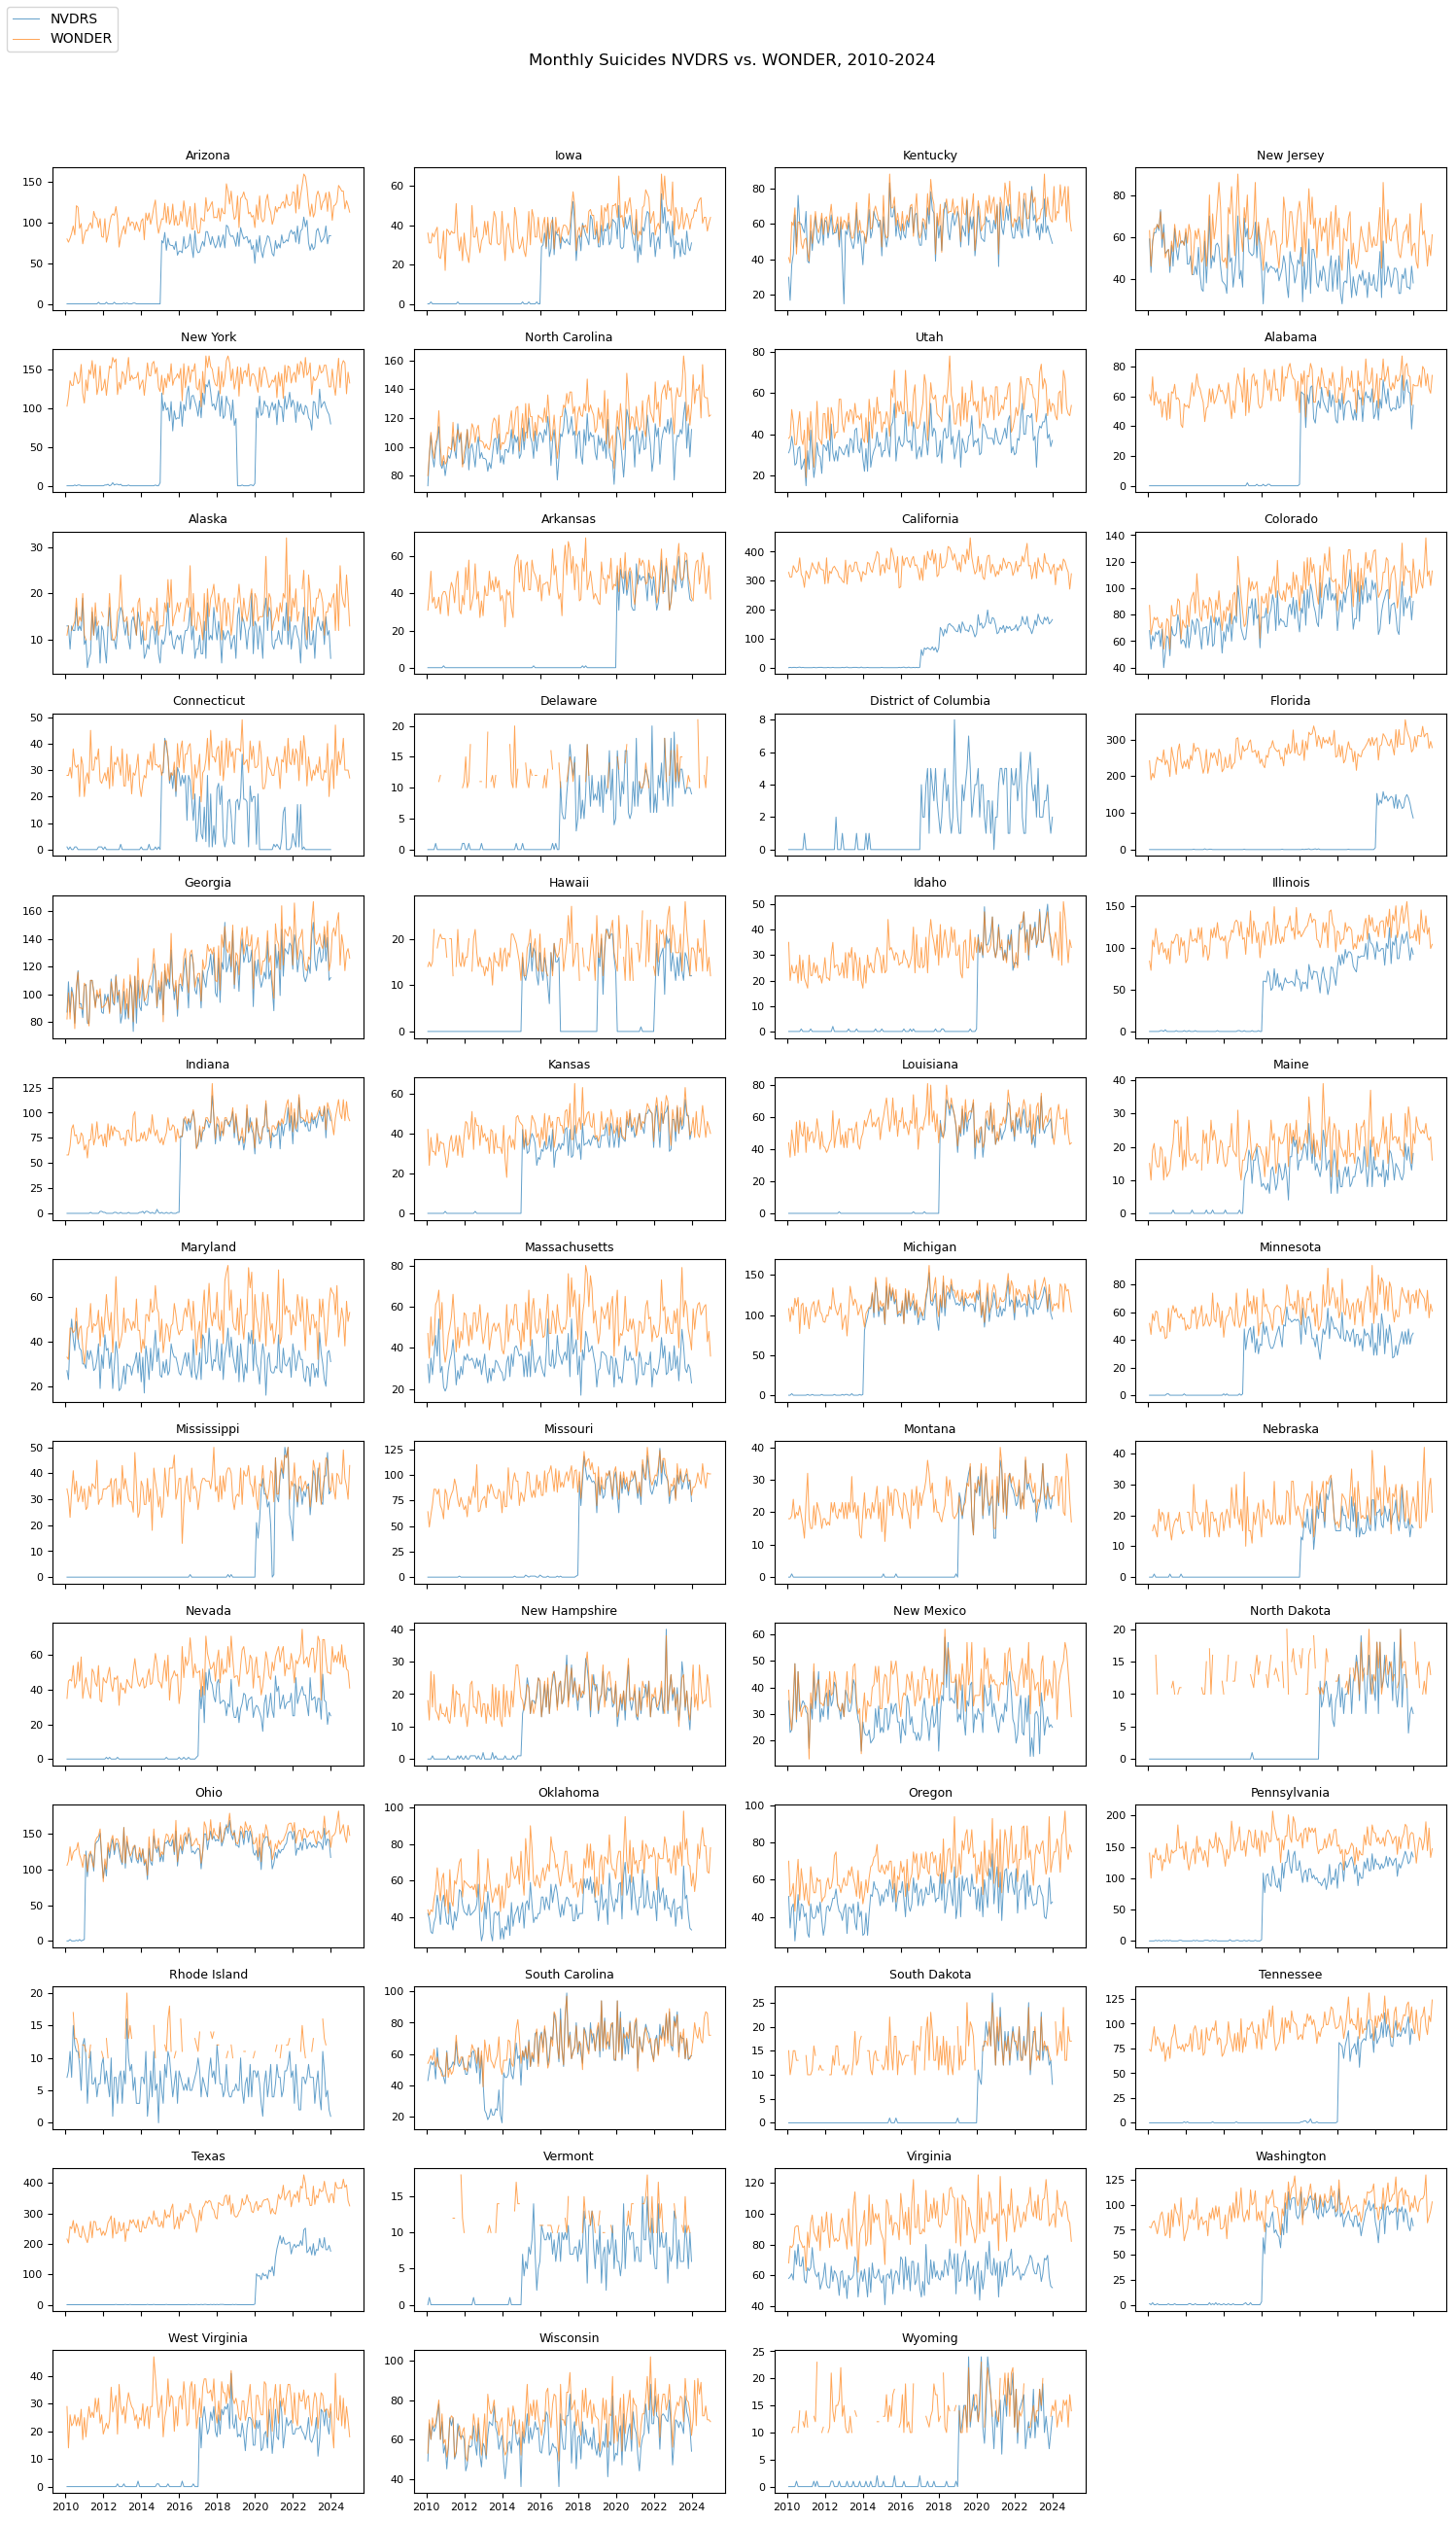

In [51]:
# Define your date range here
start_date = '2010-01-01'
end_date = '2024-12-31'

selected_states = ['Arizona', 'Iowa', 'Kentucky', 'New Jersey', 'New York', 'North Carolina', 'Utah']

all_states = selected_states = [
    'Arizona', 'Iowa', 'Kentucky', 'New Jersey', 'New York', 'North Carolina', 'Utah', 
    'Alabama', 'Alaska', 'Arkansas', 'California', 'Colorado', 'Connecticut', 'Delaware', 
    'District of Columbia', 'Florida', 'Georgia', 'Hawaii', 'Idaho', 'Illinois', 'Indiana', 
    'Kansas', 'Louisiana', 'Maine', 'Maryland', 'Massachusetts', 'Michigan', 'Minnesota', 
    'Mississippi', 'Missouri', 'Montana', 'Nebraska', 'Nevada', 'New Hampshire', 'New Mexico', 
    'North Dakota', 'Ohio', 'Oklahoma', 'Oregon', 'Pennsylvania', 'Rhode Island', 
    'South Carolina', 'South Dakota', 'Tennessee', 'Texas', 'Vermont', 'Virginia', 
    'Washington', 'West Virginia', 'Wisconsin', 'Wyoming'
]


cols = 4
rows = math.ceil(len(selected_states) / cols)

fig, axes = plt.subplots(rows, cols, figsize=(15, 2*rows), sharex=True)
axes = axes.flatten()

for i, state in enumerate(selected_states):
    ax = axes[i]
    
    # Plot NVDRS data
    if state in nvdrs_df.columns:
        subset_nvdrs = nvdrs_df.loc[start_date:end_date]
        ax.plot(subset_nvdrs.index, subset_nvdrs[state], linestyle='-', alpha=0.7, lw=0.7, label='NVDRS' if i==0 else "")
        
    # Plot WONDER data
    if state in wnd_df.columns:
        subset_wnd = wnd_df.loc[start_date:end_date]
        ax.plot(subset_wnd.index, subset_wnd[state], linestyle='-', alpha=0.7, lw=0.7, label='WONDER' if i==0 else "")
        
    ax.set_title(state)
    #ax.set_ylabel('Deaths')

# Remove empty subplots
for j in range(len(selected_states), len(axes)):
    fig.delaxes(axes[j])

fig.suptitle('Monthly Suicides NVDRS vs. WONDER, 2010-2024', fontsize=12)
fig.legend(loc='upper left')
plt.tight_layout(rect=[0, 0, 1, 0.96])
# Decrease text size for labels and titles across all axes
for ax in axes:
    ax.set_title(ax.get_title(), fontsize=9)
    ax.tick_params(axis='both', labelsize=8)
plt.show()